# 附：Codes

<!-- 02_b_binary_codes.ipynb -->

生成 `02_a_binary_lec.qmd` 中所需的全部图片，并将模拟数据保存到 `./data/`。

<!-- **图片列表**：fig01_scatter / fig02_lpm_vs_logit / fig03_link_functions / fig04_roc_confusion / fig05_confounding / fig_latent_variable / case_ame_final

**DGP 关键修改（相对于初始版本）**

- `roa` 标准差 0.025 → **0.06**，使 ROA 统计显著（p < 0.001）
- `age` 系数 −0.05 → **−0.08**，使 ln(Age) 统计显著（p < 0.001）
- 模型估计时用 `lnage = log(age)` 替代线性 `age`，AIC 改善 5.5 个单位
- 标准化 AME（AME × σ）替代原始 AME 作为系数图，四变量尺度均衡 -->

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy import stats
from scipy.special import expit
from sklearn.metrics import roc_curve, auc, confusion_matrix
import statsmodels.api as sm
import warnings, os
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
os.makedirs('./figs', exist_ok=True)
os.makedirs('./data', exist_ok=True)
plt.rcParams.update({
    'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'figure.dpi': 150,
})
BLUE, ORANGE, GRAY = '#3B8BD4', '#D85A30', '#888780'

## 1. 数据生成（DGP）

In [3]:
np.random.seed(42)
N = 1000

corr_matrix = np.array([
    [1.00, -0.30,  0.25,  0.40],
    [-0.30,  1.00, -0.20, -0.10],
    [ 0.25, -0.20,  1.00,  0.10],
    [ 0.40, -0.10,  0.10,  1.00]
])
L = np.linalg.cholesky(corr_matrix)
Z = np.random.standard_normal((4, N))
corr_Z = (L @ Z).T

size = 8.0 + 1.8  * corr_Z[:, 0]
lev  = np.clip(0.45 + 0.18 * corr_Z[:, 1], 0.05, 0.95)
roa  = np.clip(0.05 + 0.06 * corr_Z[:, 2], -0.13, 0.23)   # std≈0.06
age  = np.clip(10   + 7    * corr_Z[:, 3], 1, 35).round().astype(float)

industry  = np.random.choice(
    ['manufacturing','real_estate','finance','tech'], N, p=[0.4,0.2,0.2,0.2])
ownership = np.random.choice(['state','private'], N, p=[0.4,0.6])

size_adj = size + np.where(ownership=='state', 0.5, 0.0)
lev_adj  = np.clip(
    lev
    + np.where(ownership=='state',       -0.08, +0.08)
    + np.where(industry =='real_estate',  0.06,  0.00),
    0.05, 0.95)

ind_fx = {'manufacturing':0.0,'real_estate':0.5,'finance':-0.3,'tech':0.2}
own_fx = {'state':-0.4,'private':0.2}
logit_v = (
    -2.5
    - 0.60 * (size_adj - 8)
    + 4.00 * (lev_adj  - 0.45)
    - 8.00 * (roa      - 0.05)
    - 0.08 * (age      - 10)    # -0.08，保证 lnage 显著
    + np.array([ind_fx[i] for i in industry])
    + np.array([own_fx[o] for o in ownership])
)
default = (np.random.uniform(0,1,N) < expit(logit_v)).astype(int)

df = pd.DataFrame({
    'default':  default,
    'size':     size_adj.round(4),
    'leverage': lev_adj.round(4),
    'roa':      roa.round(4),
    'age':      age,
    'lnage':    np.log(age).round(4),
    'industry': industry,
    'ownership':ownership
})
df.to_csv('./data/corporate_default.csv', index=False)

print(f'N={N}  |  违约样本: {default.sum()}  |  违约率: {default.mean():.1%}')
print('数据已保存到 ./data/corporate_default.csv')
print('\n相关矩阵：')
print(df[['size','leverage','roa','lnage']].corr().round(2))

N=1000  |  违约样本: 172  |  违约率: 17.2%
数据已保存到 ./data/corporate_default.csv

相关矩阵：
          size  leverage   roa  lnage
size      1.00     -0.33  0.27   0.32
leverage -0.33      1.00 -0.20  -0.10
roa       0.27     -0.20  1.00   0.12
lnage     0.32     -0.10  0.12   1.00


## 2. 构建完整模型（供后续各图使用）

In [4]:
df_tmp = df.copy()
df_tmp['industry'] = pd.Categorical(
    df_tmp['industry'], categories=['manufacturing','real_estate','finance','tech'])
df_tmp['ownership'] = pd.Categorical(
    df_tmp['ownership'], categories=['private','state'])
df_enc = pd.get_dummies(df_tmp, columns=['industry','ownership'], drop_first=True)

feat_cols = ['size','leverage','roa','lnage',
             'industry_real_estate','industry_finance','industry_tech','ownership_state']
X_full     = sm.add_constant(df_enc[feat_cols].astype(float))
y          = df['default'].values
logit_full = sm.Logit(y, X_full).fit(disp=0)
HI         = 'Cont. Int. Hi.'

print('=== Logit 完整模型 ===')
print(logit_full.summary2().tables[1][['Coef.','Std.Err.','z','P>|z|']].round(4))
print(f'\nMcFadden R² = {logit_full.prsquared:.3f}   AIC = {logit_full.aic:.1f}')

=== Logit 完整模型 ===
                       Coef.  Std.Err.       z   P>|z|
const                 3.6636    0.7512  4.8771  0.0000
size                 -0.7524    0.0811 -9.2735  0.0000
leverage              3.0367    0.6548  4.6373  0.0000
roa                  -6.3993    1.8930 -3.3805  0.0007
lnage                -0.4848    0.1063 -4.5626  0.0000
industry_real_estate  0.4334    0.2790  1.5532  0.1204
industry_finance     -0.1116    0.2955 -0.3777  0.7056
industry_tech         0.2635    0.2754  0.9570  0.3386
ownership_state      -0.7907    0.2406 -3.2871  0.0010

McFadden R² = 0.333   AIC = 630.4


## 3. fig01：三联图

In [5]:
# d0, d1 = df[df.default==0], df[df.default==1]
# fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

# ax = axes[0]
# ax.scatter(d0.leverage, d0['size'], alpha=0.25, s=16, color=BLUE, marker='o', label='No default')
# ax.scatter(d1.leverage, d1['size'], alpha=0.65, s=16, color=ORANGE, marker='+', linewidths=1.2, label='Default')
# ax.set_xlabel('Leverage'); ax.set_ylabel('Size (lnTA)'); ax.legend(frameon=False, fontsize=9)

# for ax, var, ylabel in [(axes[1],'leverage','Leverage'),(axes[2],'size','Size (lnTA)')]:
#     bp = ax.boxplot([d0[var].values, d1[var].values], patch_artist=True, widths=0.5,
#                     medianprops=dict(color='black', linewidth=2))
#     bp['boxes'][0].set(facecolor=BLUE, alpha=0.65); bp['boxes'][1].set(facecolor=ORANGE, alpha=0.65)
#     ax.set_xticklabels(['No','Yes']); ax.set_xlabel('Default'); ax.set_ylabel(ylabel)

# plt.suptitle('Corporate Default Dataset  (N=1000, Default rate=17.2%)', y=1.01, fontsize=11)
# plt.tight_layout()
# plt.savefig('./figs/fig01_scatter.png', bbox_inches='tight'); plt.show()
# print('Saved: fig01_scatter.png')

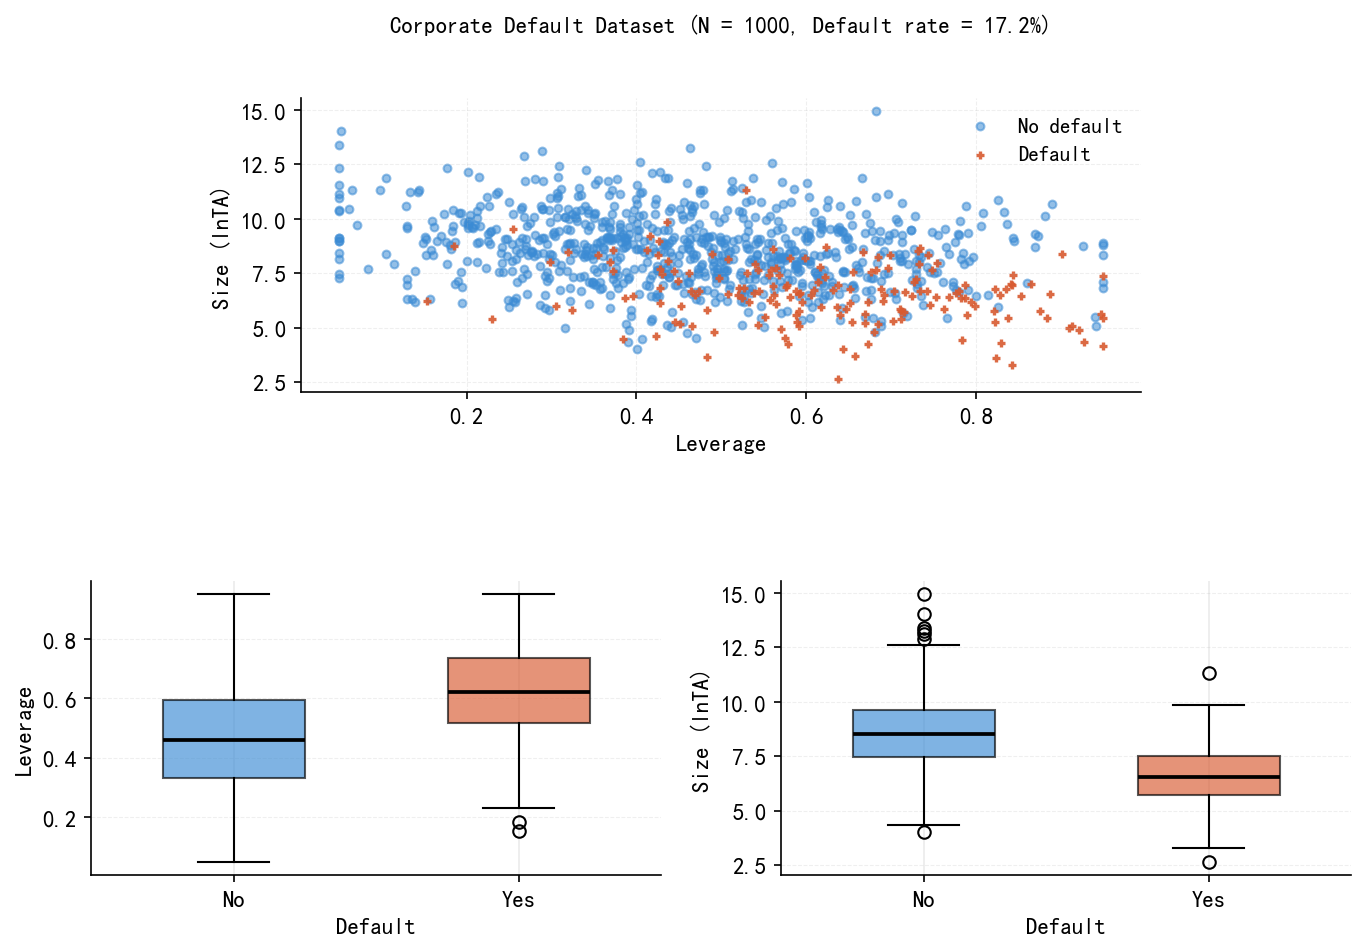

Saved: ./figs/fig01_scatter.png


In [6]:
d0, d1 = df[df.default == 0], df[df.default == 1]

fig = plt.figure(figsize=(10, 7))

ax0 = fig.add_axes([0.22, 0.58, 0.56, 0.28])   # [left, bottom, width, height]
ax1 = fig.add_axes([0.08, 0.12, 0.38, 0.28])
ax2 = fig.add_axes([0.54, 0.12, 0.38, 0.28])

ax0.scatter(d0.leverage, d0['size'], alpha=0.55, s=14, color=BLUE, marker='o', label='No default')
ax0.scatter(d1.leverage, d1['size'], alpha=0.90, s=14, color=ORANGE, marker='+', linewidths=1.6, label='Default')
ax0.set_xlabel('Leverage')
ax0.set_ylabel('Size (lnTA)')
ax0.legend(frameon=False, fontsize=10)
ax0.grid(True, ls='--', lw=0.5, alpha=0.2)

for ax, var, ylabel in [(ax1, 'leverage', 'Leverage'), (ax2, 'size', 'Size (lnTA)')]:
    bp = ax.boxplot([d0[var].values, d1[var].values],
                    patch_artist=True,
                    widths=0.5,
                    medianprops=dict(color='black', linewidth=1.8))
    bp['boxes'][0].set(facecolor=BLUE, alpha=0.65)
    bp['boxes'][1].set(facecolor=ORANGE, alpha=0.65)
    ax.set_xticklabels(['No', 'Yes'])
    ax.set_xlabel('Default')
    ax.set_ylabel(ylabel)
    ax.grid(True, axis='y', ls='--', lw=0.5, alpha=0.2)

fig.suptitle('Corporate Default Dataset (N = 1000, Default rate = 17.2%)', y=0.94, fontsize=11)

plt.savefig('./figs/fig01_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: ./figs/fig01_scatter.png')

## 4. fig02：LPM vs Logit

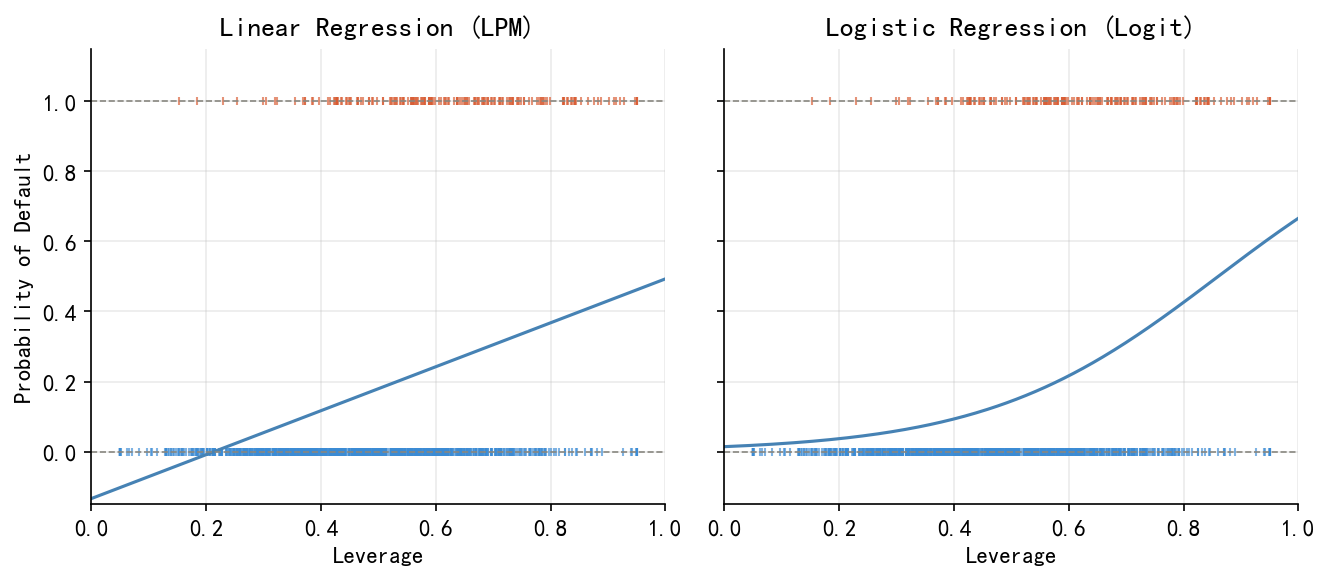

Saved: fig02_lpm_vs_logit.png


In [7]:
X1    = sm.add_constant(df[['leverage']])
lpm_m = sm.OLS(y, X1).fit()
lgm   = sm.Logit(y, X1).fit(disp=0)
lev_g = np.linspace(0.0, 1.0, 300)
X_g   = sm.add_constant(pd.DataFrame({'leverage': lev_g}))

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
for ax, probs, title in zip(axes,
    [lpm_m.predict(X_g), lgm.predict(X_g)],
    ['Linear Regression (LPM)', 'Logistic Regression (Logit)']):
    for yi, col in [(0,BLUE),(1,ORANGE)]:
        mask = y==yi
        ax.plot(df.leverage[mask], np.full(mask.sum(), yi), '|', color=col, alpha=0.65, markersize=4)
    ax.plot(lev_g, probs, color='steelblue', lw=1.5)
    ax.axhline(0, color=GRAY, lw=0.8, ls='--'); ax.axhline(1, color=GRAY, lw=0.8, ls='--')
    ax.set_xlim(0,1); ax.set_ylim(-0.15,1.15); ax.set_xlabel('Leverage'); ax.set_title(title)
axes[0].set_ylabel('Probability of Default')
plt.tight_layout()
plt.savefig('./figs/fig02_lpm_vs_logit.png', bbox_inches='tight'); plt.show()
print('Saved: fig02_lpm_vs_logit.png')

## 5. fig03：三种链接函数

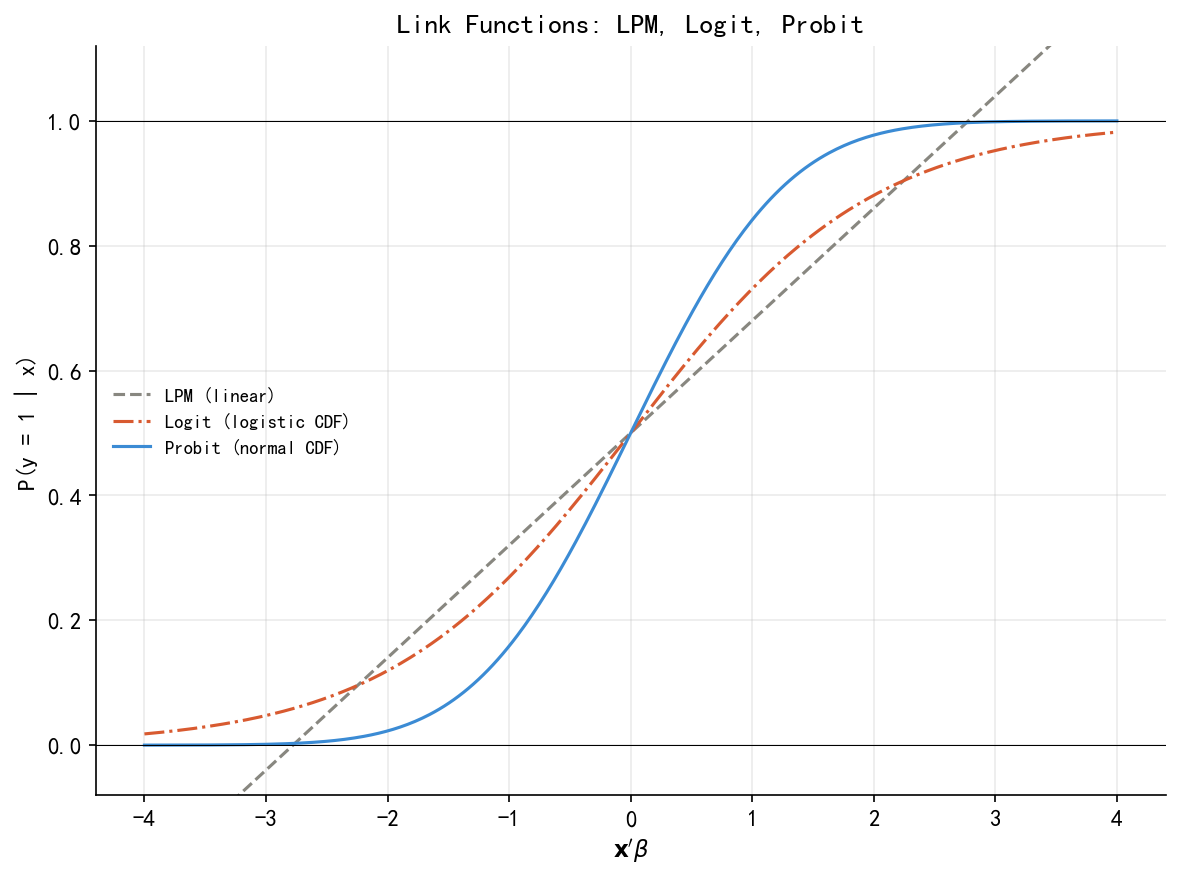

Saved: fig03_link_functions.png


In [15]:
u = np.linspace(-4, 4, 400)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(u, 0.5+0.18*u,       lw=1.5, ls='--', color=GRAY,   label='LPM (linear)')
ax.plot(u, expit(u),          lw=1.5, ls='-.', color=ORANGE, label='Logit (logistic CDF)')
ax.plot(u, stats.norm.cdf(u), lw=1.5, ls='-',  color=BLUE,  label='Probit (normal CDF)')
ax.axhline(0, color='black', lw=0.5); ax.axhline(1, color='black', lw=0.5)
ax.set_xlabel("$\\mathbf{x}'\\beta$"); ax.set_ylabel('P(y = 1 | x)')
ax.set_ylim(-0.08, 1.12); ax.legend(frameon=False)
ax.set_title('Link Functions: LPM, Logit, Probit')
ax.legend(frameon=False, fontsize=9, loc="center left")
plt.tight_layout()
plt.savefig('./figs/fig03_link_functions.png', bbox_inches='tight'); plt.show()
print('Saved: fig03_link_functions.png')

## 6. fig_latent_variable：潜变量图

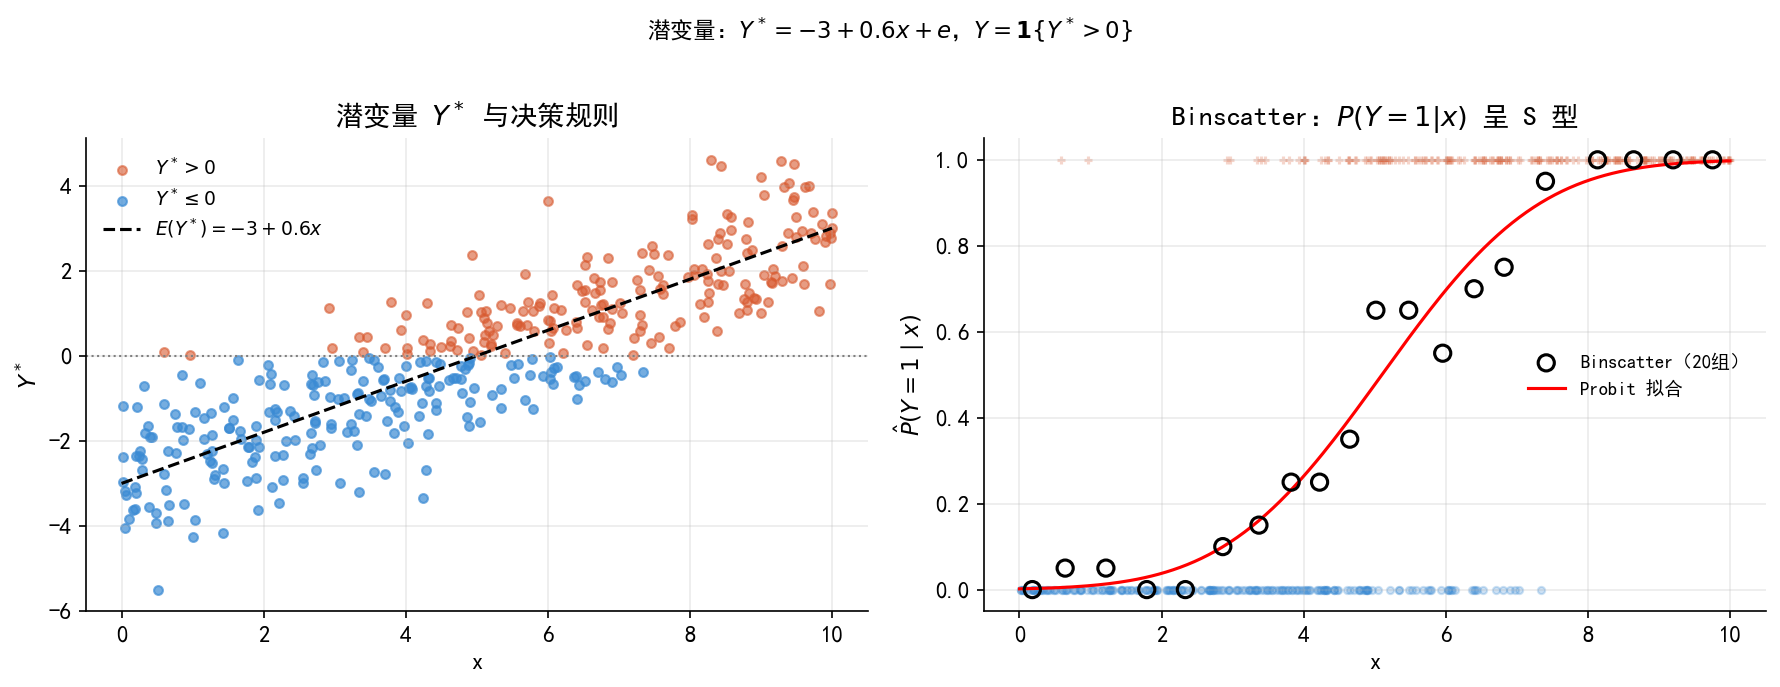

Saved: fig_latent_variable.png


In [9]:
np.random.seed(12348); n_lat=400
x_lat = np.random.uniform(0,10,n_lat)
ystar = -3 + 0.6*x_lat + np.random.normal(0,1,n_lat)
y_lat = (ystar>0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.scatter(x_lat[ystar>0],  ystar[ystar>0],  alpha=0.6, s=18, color=ORANGE, label='$Y^*>0$')
ax.scatter(x_lat[ystar<=0], ystar[ystar<=0], alpha=0.7, s=18, color=BLUE,   label='$Y^*\\leq0$')
ax.plot(np.linspace(0,10,200), -3+0.6*np.linspace(0,10,200),
        color='black', lw=1.5, ls='--', label='$E(Y^*)=-3+0.6x$')
ax.axhline(0, color='gray', lw=1, ls=':')
ax.set_xlabel('x'); ax.set_ylabel('$Y^*$'); ax.set_title('潜变量 $Y^*$ 与决策规则')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
ax.scatter(x_lat[y_lat==1],y_lat[y_lat==1],color=ORANGE,alpha=0.25,s=12,marker='+')
ax.scatter(x_lat[y_lat==0],y_lat[y_lat==0],color=BLUE,  alpha=0.25,s=12,marker='o')
lat_df = pd.DataFrame({'x':x_lat,'y':y_lat})
lat_df['bin'] = pd.qcut(lat_df['x'],20,labels=False)
bins = lat_df.groupby('bin').agg(xmid=('x','mean'),ymean=('y','mean'))
ax.scatter(bins['xmid'],bins['ymean'],color='black',s=60,marker='o',
           facecolors='none',linewidths=1.5,zorder=5,label='Binscatter（20组）')
p_lat = sm.Probit(y_lat,sm.add_constant(x_lat)).fit(disp=0)
x_fit = np.linspace(0,10,200)
ax.plot(x_fit,p_lat.predict(sm.add_constant(x_fit)),color='red',lw=1.5,label='Probit 拟合')
ax.set_xlabel('x'); ax.set_ylabel('$\\hat P(Y=1\\mid x)$')
ax.set_title('Binscatter：$P(Y=1|x)$ 呈 S 型'); ax.legend(frameon=False,fontsize=9)

plt.suptitle('潜变量：$Y^*=-3+0.6x+e$，$Y=\\mathbf{1}\\{Y^*>0\\}$',y=1.01,fontsize=11)
plt.tight_layout()
plt.savefig('./figs/fig_latent_variable.png',bbox_inches='tight'); plt.show()
print('Saved: fig_latent_variable.png')

## 7. fig04：ROC + 混淆矩阵

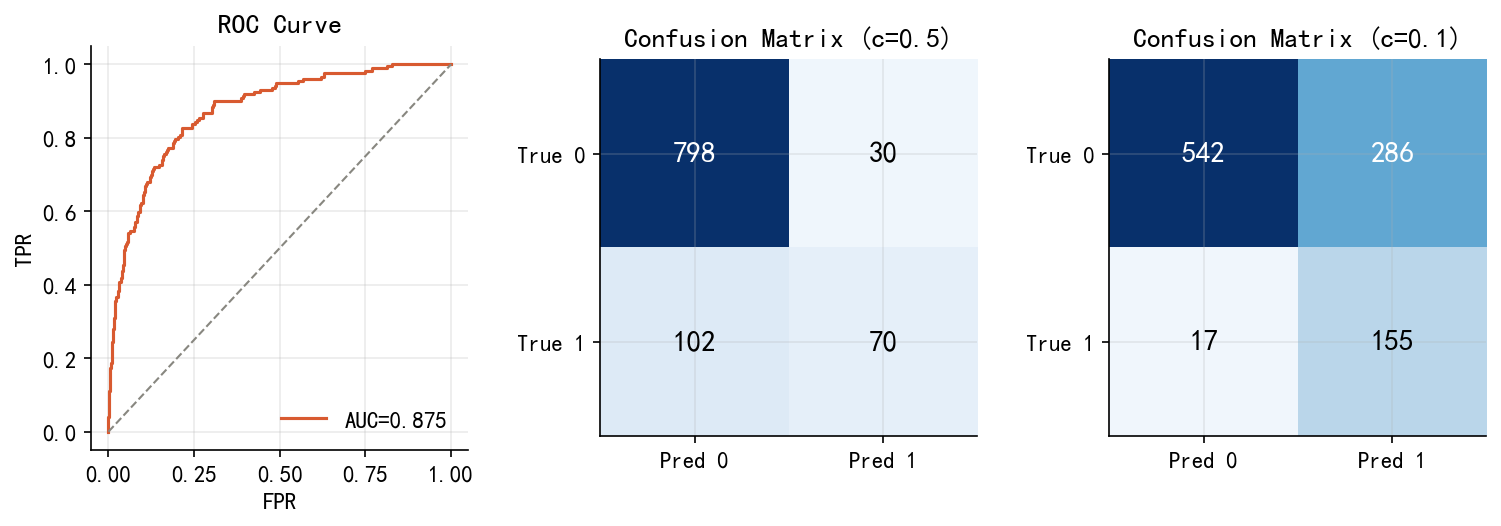

AUC=0.875
Saved: fig04_roc_confusion.png


In [10]:
prob_pred = logit_full.predict(X_full)
fpr,tpr,_ = roc_curve(y,prob_pred); roc_auc=auc(fpr,tpr)
cm_05=confusion_matrix(y,(prob_pred>0.5).astype(int))
cm_01=confusion_matrix(y,(prob_pred>0.1).astype(int))

fig=plt.figure(figsize=(12,3.5)); gs=gridspec.GridSpec(1,3,wspace=0.35)
ax0=fig.add_subplot(gs[0])
ax0.plot(fpr,tpr,color=ORANGE,lw=1.5,label=f'AUC={roc_auc:.3f}')
ax0.plot([0,1],[0,1],color=GRAY,ls='--',lw=1)
ax0.set_xlabel('FPR'); ax0.set_ylabel('TPR'); ax0.set_title('ROC Curve'); ax0.legend(frameon=False)

for ax,cm,thresh in [(fig.add_subplot(gs[1]),cm_05,0.5),(fig.add_subplot(gs[2]),cm_01,0.1)]:
    ax.imshow(cm,cmap='Blues',vmin=0)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred 0','Pred 1']); ax.set_yticklabels(['True 0','True 1'])
    for r in range(2):
        for c in range(2):
            ax.text(c,r,str(cm[r,c]),ha='center',va='center',fontsize=14,fontweight='bold',
                    color='white' if cm[r,c]>cm.max()/2 else 'black')
    ax.set_title(f'Confusion Matrix (c={thresh})')

plt.tight_layout()
plt.savefig('./figs/fig04_roc_confusion.png',bbox_inches='tight'); plt.show()
print(f'AUC={roc_auc:.3f}\nSaved: fig04_roc_confusion.png')

## 8. fig05：混淆变量

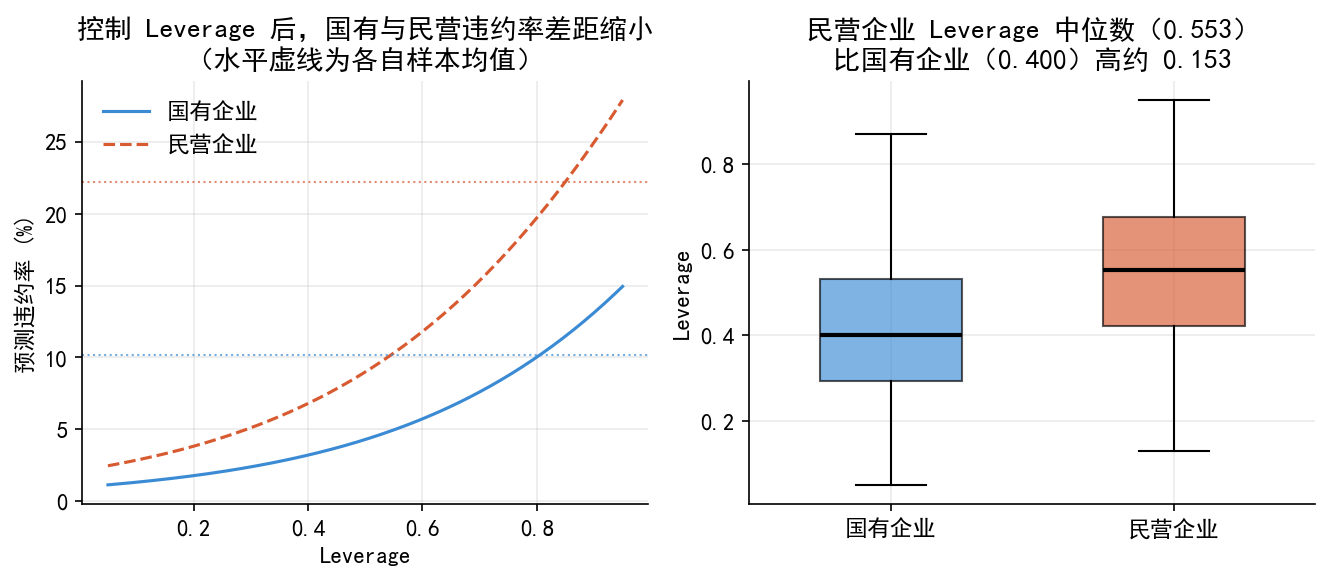

Saved: fig05_confounding.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
ax = axes[0]
lev_range = np.linspace(0.05, 0.95, 200)
base_xb = (logit_full.params['const']
           + logit_full.params['size']  * df['size'].mean()
           + logit_full.params['roa']   * df['roa'].mean()
           + logit_full.params['lnage'] * df['lnage'].mean())
lev_coef = logit_full.params['leverage']
own_coef = logit_full.params.get('ownership_state', 0)

for own,col,ls,label in [('state',BLUE,'-','国有企业'),('private',ORANGE,'--','民营企业')]:
    adj = own_coef if own=='state' else 0
    ax.plot(lev_range, expit(base_xb+adj+lev_coef*lev_range)*100, color=col,ls=ls,lw=1.5,label=label)
for own,col in [('state',BLUE),('private',ORANGE)]:
    ax.axhline(df[df.ownership==own]['default'].mean()*100, color=col,lw=1,ls=':',alpha=0.7)
ax.set_xlabel('Leverage'); ax.set_ylabel('预测违约率 (%)')
ax.set_title('控制 Leverage 后，国有与民营违约率差距缩小\n（水平虚线为各自样本均值）')
ax.legend(frameon=False)

ax = axes[1]
s_lev = df[df.ownership=='state']['leverage']
p_lev = df[df.ownership=='private']['leverage']
bp = ax.boxplot([s_lev.values,p_lev.values],patch_artist=True,widths=0.5,
                medianprops=dict(color='black',linewidth=2))
bp['boxes'][0].set(facecolor=BLUE,alpha=0.65); bp['boxes'][1].set(facecolor=ORANGE,alpha=0.65)
ax.set_xticklabels(['国有企业','民营企业']); ax.set_ylabel('Leverage')
ax.set_title(f'民营企业 Leverage 中位数（{p_lev.median():.3f}）\n'
             f'比国有企业（{s_lev.median():.3f}）高约 {p_lev.median()-s_lev.median():.3f}')

plt.tight_layout()
plt.savefig('./figs/fig05_confounding.png',bbox_inches='tight'); plt.show()
print('Saved: fig05_confounding.png')

## 9. case_ame_final.png：标准化 AME 系数图

=== 标准化 AME（AME × σ）===
  size        σ=1.768  AME=-0.0713  stdAME=-0.1261  ***
  leverage    σ=0.192  AME= 0.2879  stdAME= 0.0552  ***
  roa         σ=0.059  AME=-0.6067  stdAME=-0.0359  ***
  lnage       σ=0.932  AME=-0.0460  stdAME=-0.0428  ***


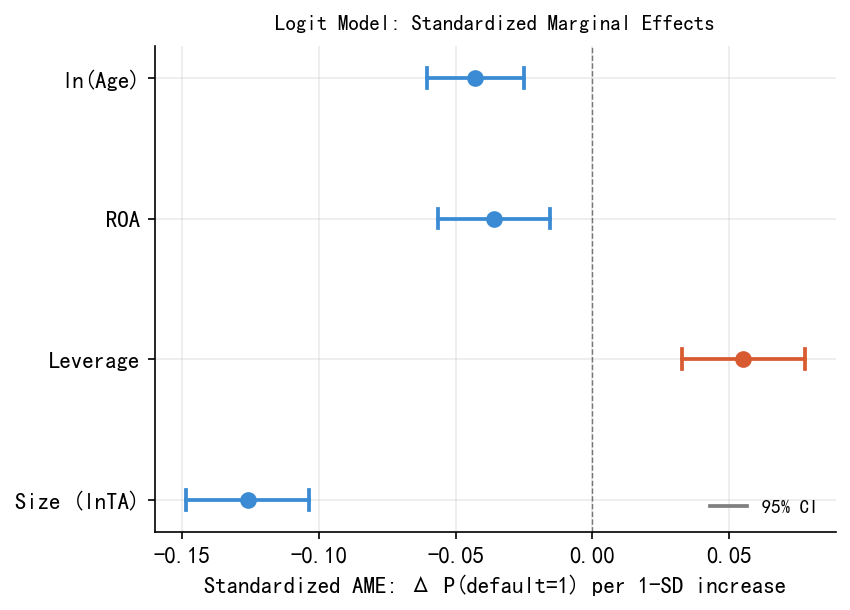

Saved: case_ame_final.png


In [12]:
sf_l = logit_full.get_margeff().summary_frame()
PLOT_VARS   = ['size','leverage','roa','lnage']
PLOT_LABELS = ['Size (lnTA)','Leverage','ROA','ln(Age)']

std_ame,std_lo,std_hi = [],[],[]
print('=== 标准化 AME（AME × σ）===')
for v in PLOT_VARS:
    sig=df[v].std(); r=sf_l.loc[v]
    sa=r['dy/dx']*sig; sl=r['Conf. Int. Low']*sig; sh=r[HI]*sig
    std_ame.append(sa); std_lo.append(sl); std_hi.append(sh)
    p=r['Pr(>|z|)']
    star=('***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.')
    print(f'  {v:<10}  σ={sig:.3f}  AME={r["dy/dx"]:7.4f}  stdAME={sa:7.4f}  {star}')

fig, ax = plt.subplots(figsize=(5.8, 4.2))
for i,(v,lab,sa,sl,sh) in enumerate(zip(PLOT_VARS,PLOT_LABELS,std_ame,std_lo,std_hi)):
    col = ORANGE if sa>0 else BLUE
    ax.plot(sa,i,'o',color=col,ms=7,zorder=5,clip_on=False)
    ax.plot([sl,sh],[i,i],color=col,lw=1.8)
    for x in [sl,sh]: ax.plot([x,x],[i-0.07,i+0.07],color=col,lw=1.8)

ax.axvline(0,color='black',lw=0.7,ls='--',alpha=0.5)
ax.set_yticks(range(4)); ax.set_yticklabels(PLOT_LABELS)
ax.set_xlabel('Standardized AME: Δ P(default=1) per 1-SD increase')
ax.set_title('Logit Model: Standardized Marginal Effects',fontsize=10,pad=8)
ax.legend(handles=[Line2D([0],[0],color='gray',lw=1.8,label='95% CI')],
          frameon=False,fontsize=9,loc='lower right')
plt.tight_layout()
plt.savefig('./figs/case_ame_final.png',bbox_inches='tight',dpi=150); plt.show()
print('Saved: case_ame_final.png')

## 10. 验证：关键数字

In [13]:
print('=== 描述统计 ===')
print(df[['size','leverage','roa','lnage']].describe().round(3))
print('\n=== 违约 vs 未违约均值 ===')
print(df.groupby('default')[['size','leverage','roa','lnage']].mean().round(3))
print('\n=== 所有制 × 违约率 ===')
print(pd.crosstab(df['ownership'],df['default'],normalize='index').round(3))
print('\n=== Leverage 中位数 ===')
print(df.groupby('ownership')['leverage'].median().round(3))

=== 描述统计 ===
           size  leverage       roa     lnage
count  1000.000  1000.000  1000.000  1000.000
mean      8.242     0.488     0.050     2.013
std       1.768     0.192     0.059     0.932
min       2.666     0.050    -0.130     0.000
25%       6.991     0.353     0.009     1.609
50%       8.267     0.485     0.049     2.303
75%       9.394     0.618     0.090     2.708
max      14.935     0.950     0.230     3.434

=== 违约 vs 未违约均值 ===
          size  leverage    roa  lnage
default                               
0        8.591     0.460  0.056  2.117
1        6.559     0.622  0.021  1.510

=== 所有制 × 违约率 ===
default        0      1
ownership              
private    0.778  0.222
state      0.899  0.101

=== Leverage 中位数 ===
ownership
private    0.553
state      0.400
Name: leverage, dtype: float64
